In [1]:
import sys
!{sys.executable} -m pip install /content/GraphHDBSCAN.zip

Processing ./GraphHDBSCAN_star_v0.2.9.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.2/624.2 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.6/159.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from coresg_graphhdbscan import GraphCoreSGHDBSCAN

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
import yaml
import scanpy as sc
from sklearn.neighbors import NearestNeighbors as NN
from sklearn.metrics import pairwise_distances
# Load the YAML configuration file
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

Zheng_config = config["DATASETS"]["Zheng"]
expected_cell_label = Zheng_config["cell_labels"]

adata = sc.read_h5ad("/content/Zheng.h5ad")
# Print available columns in adata.obs
available_columns = list(adata.obs.columns)
print("Available columns in adata.obs:", available_columns)

cell_label_key = expected_cell_label

# Extract the count matrix and cell labels
count_matrix = adata.X  # Cells as rows and genes as columns
true_labels = adata.obs[cell_label_key]
print(true_labels)
# Print some basic information about the data
print("Count matrix shape:", count_matrix.shape)
print("First few cell labels:")
print(true_labels.head())


Available columns in adata.obs: ['label', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'norm_factor']
AAACATTGTTTCAC-1_cd56_nk    cd56_nk
AAACTTGAGCCTTC-1_cd56_nk    cd56_nk
AAAGACGACTCTCG-1_cd56_nk    cd56_nk
AAAGCAGATGCAAC-1_cd56_nk    cd56_nk
AAAGCAGATGGTTG-1_cd56_nk    cd56_nk
                             ...   
TTTGACTGTCAGAC-1_cd34          cd34
TTTGACTGTTGAGC-1_cd34          cd34
TTTGCATGCCTACC-1_cd34          cd34
TTTGCATGCTGGTA-1_cd34          cd34
TTTGCATGGCTATG-1_cd34          cd34
Name: label, Length: 8508, dtype: category
Categories (9, object): ['cd56_nk', 'cd4_t_helper', 'regulatory_t', 'memory_t', ...,
                         'naive_cytotoxic', 'cytotoxic_t', 'b_cells', 'cd34']
Count matrix shape: (8508, 1000)
First few cell labels:
AAACATTGTTTCAC-1_cd56_nk    cd56_nk
AAACTTGAGCCTTC-1_cd56_nk    cd56_nk
AAAGACGACTCTCG-1_cd56_nk    cd56_nk
AAAGCAGATGCAAC-1_cd56_nk    cd56_nk
AAAGCAGATGGTTG-1_cd56_nk    cd56_nk
Name: label, dtype: c

In [7]:
g = GraphCoreSGHDBSCAN(
    min_samples=range(2,10),
    sim_graph_method="jaccard_phenograph",
    n_neighbors=7,
    no_noise=True,
    metric="euclidean",
    min_cluster_size=60
)


In [8]:
g.fit(adata.X)

Using neighbor information from provided graph, rather than computing neighbors directly
Jaccard graph constructed in 0.3859875202178955 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.5253403186798096 seconds
[CORE-SG] (precomputed) CORE-SG graph has 1847277 edges
[CORE-SG] m= 2: MST+tree+labels in 0.6208s
[CORE-SG] m= 3: MST+tree+labels in 0.5811s
[CORE-SG] m= 4: MST+tree+labels in 0.5659s
[CORE-SG] m= 5: MST+tree+labels in 0.6083s
[CORE-SG] m= 6: MST+tree+labels in 0.6084s
[CORE-SG] m= 7: MST+tree+labels in 0.6056s
[CORE-SG] m= 8: MST+tree+labels in 0.5333s
[CORE-SG] m= 9: MST+tree+labels in 0.5916s


GraphCoreSGHDBSCAN(min_samples_list=[2, 3, 4, 5, 6, 7, 8, 9], metric='euclidean', eps=1e-12, min_cluster_size=60, X_=None, N_=None, D_=None, core_={}, kmax_=None, edges_ut_=None, idx_with_self_=None, dst_with_self_=None, idx_no_self_=None, dst_no_self_=None, A_knn_=None, msts_={}, mst_times_={}, models_={}, times_={})

In [9]:
g.interactive_condensed_tree()

SelectionSlider(continuous_update=False, description='m', layout=Layout(width='500px'), options=(2, 3, 4, 5, 6…

<Axes: title={'center': 'Condensed Tree for m = 7'}, ylabel='$\\lambda$ value'>

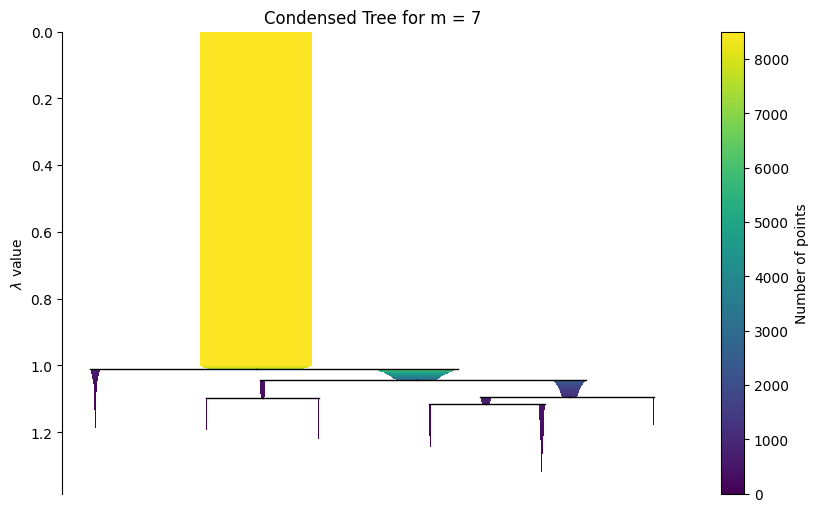

In [12]:
g.plot_condensed_tree(7)

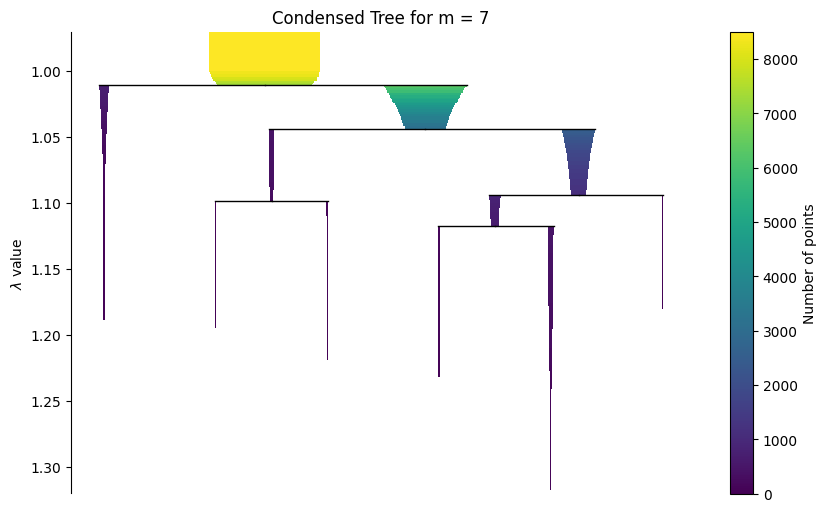

In [11]:
import matplotlib.pyplot as plt

ax = g.plot_condensed_tree(7)
ax.set_ylim(1.32, 0.97)
plt.show()